## EDA (Exploratory Data Analysis)

In [1]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Load Dataset
df = pd.read_csv("../data/processed/Cleaned-Telco-Customer-Churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Demographic & Customer Profile Analysis

### 1. Does churn vary by gender?

In [3]:
## Churn variation by gender
churn_variation_by_gender = df.groupby(['gender'])['Churn'].value_counts(normalize=True).round(2).to_frame()

churn_variation_by_gender

proportion
gender Churn            
Female No           0.73
       Yes          0.27
Male   No           0.74
       Yes          0.26

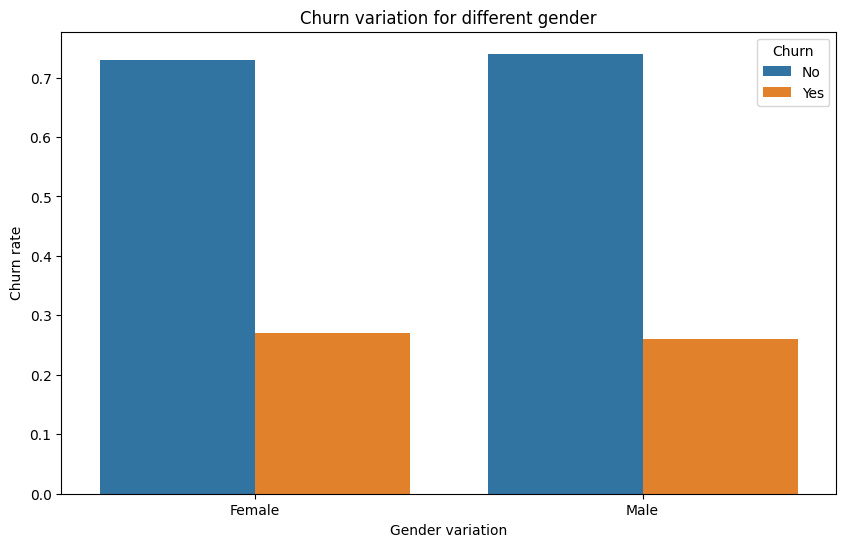

In [4]:
plt.figure(figsize=(10,6))
sns.barplot(data=churn_variation_by_gender, x='gender', y='proportion', hue='Churn')
plt.xlabel("Gender variation")
plt.ylabel("Churn rate")
plt.title("Churn variation for different gender");

#### Comments:
The above analysis indicates that:
* Churn rate is higher for female customers (approximately 27%) compared to male customers (around 26%).

### 2. Are senior citizens more likely to churn?

In [5]:
## Churn rate of senior citizen
churn_rate_of_senior_citizen = df.groupby(['SeniorCitizen'])['Churn'].value_counts(normalize=True).to_frame()

churn_rate_of_senior_citizen

proportion
SeniorCitizen Churn            
0             No       0.763476
              Yes      0.236524
1             No       0.583333
              Yes      0.416667

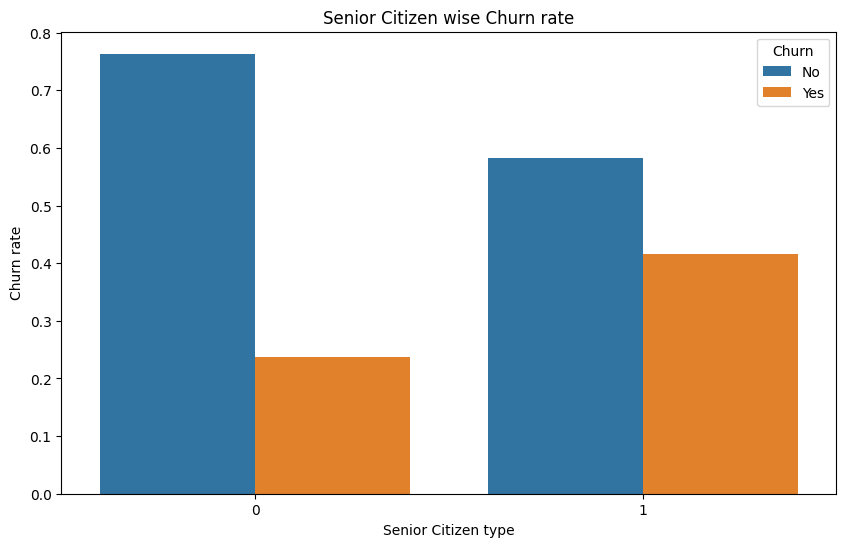

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(data=churn_rate_of_senior_citizen, x='SeniorCitizen', y='proportion', hue='Churn')
plt.xlabel("Senior Citizen type")
plt.ylabel("Churn rate")
plt.title("Senior Citizen wise Churn rate");

#### Comments:
From the above analysis we can clearly see that:
* Senior citizens have a higher churn rate (approximately 41%) compared to non-senior citizens (around 23%). 

This suggests that age may be a factor influencing customer retention, with older customers being more prone to discontinuing the service.

### 3. How does churn differ for customers with partners or dependents?

In [7]:
## How churn vary by customer partner wise
partner_wise_churn_rate = df.groupby(['Partner'])['Churn'].value_counts(normalize=True).round(2).to_frame()

partner_wise_churn_rate

proportion
Partner Churn            
No      No           0.67
        Yes          0.33
Yes     No           0.80
        Yes          0.20

In [8]:
## How churn vary by customer dependents wise
dependents_wise_churn_rate = df.groupby(['Dependents'])['Churn'].value_counts(normalize=True).round(2).to_frame()

dependents_wise_churn_rate

proportion
Dependents Churn            
No         No           0.69
           Yes          0.31
Yes        No           0.84
           Yes          0.16

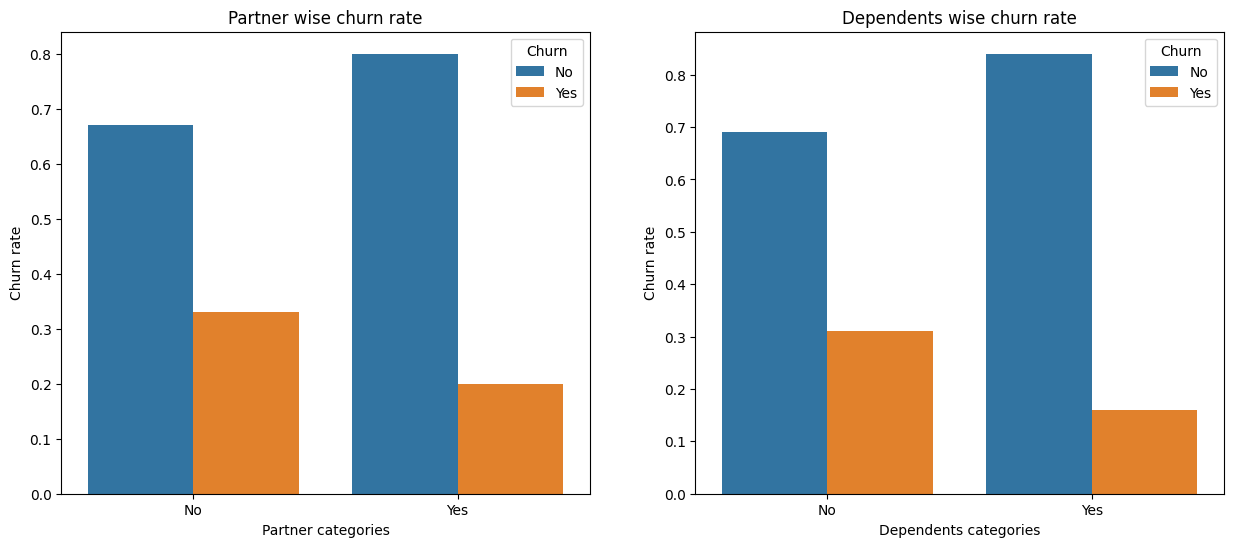

In [9]:
plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
sns.barplot(data=partner_wise_churn_rate, x='Partner', y='proportion', hue='Churn')
plt.title("Partner wise churn rate")
plt.xlabel("Partner categories")
plt.ylabel("Churn rate");

plt.subplot(1, 2, 2)
sns.barplot(data=dependents_wise_churn_rate, x='Dependents', y='proportion', hue='Churn')
plt.title("Dependents wise churn rate")
plt.xlabel("Dependents categories")
plt.ylabel("Churn rate");

#### Comments:
The above analysis shows that:
* Customers without partners have a higher churn rate (approximately 33%) compared to those with partners (around 20%).
* Similarly, customers without dependents exhibit a higher churn rate (about 31%) than those with dependents (approximately 16%).

### 4. Which demographic group has the highest churn probability?

Understanding churn rate across differnent demographic groups(gender, senior citizen, and contract type) can help in identifying vulnerable segments and tailoring retention strategies accordingly.

In [10]:
pd.pivot_table(data=df, index=['Churn', 'Partner', 'Dependents'], columns=['gender', 'SeniorCitizen'], aggfunc='size')

gender                   Female      Male     
SeniorCitizen                 0    1    0    1
Churn Partner Dependents                      
No    No      No            909  159  962  126
              Yes           110    2  166    4
      Yes     No            482  136  438  176
              Yes           710   31  713   31
Yes   No      No            428  158  418  117
              Yes            32    1   43    1
      Yes     No            113   73  128  105
              Yes           124    8  105   12

#### Comments:
* The analysis shows that there are 32 possible demographic groups based on the combinations.
* Among all possible demographic groups the one with the highest churn number is (Gender: Female, Senior Citizen: No, Partner: No, Dependents: No) with a churn count of 428.
* So this demographic group has the highest churn probability and should be targeted for retention efforts.

### 5. Is there a demographic segment that is low churn but high revenue?

In [11]:
demographic_segment_with_revenue = df.groupby(['Churn', 'gender' ,'Partner', 'SeniorCitizen', 'Dependents']).agg({'Churn' : 'size', 'TotalCharges' : 'sum'}).loc['Yes', :].sort_values(by=['TotalCharges'], ascending=False)

demographic_segment_with_revenue

Churn  TotalCharges
gender Partner SeniorCitizen Dependents                     
Male   No      0             No            418     446439.30
Female No      0             No            428     420269.30
Male   Yes     0             No            128     330260.90
               1             No            105     263073.95
Female Yes     0             No            113     245110.85
                             Yes           124     236720.05
Male   Yes     0             Yes           105     226882.90
Female No      1             No            158     211737.40
       Yes     1             No             73     184059.00
Male   No      1             No            117     156377.15
       Yes     1             Yes            12      47452.70
       No      0             Yes            43      39270.45
Female No      0             Yes            32      31095.55
       Yes     1             Yes             8      19544.15
       No      1             Yes             1         71.00
Male   No      1             Yes             1         50.15

In [12]:
demographic_segment_with_revenue['Per_churn_revenue'] = (demographic_segment_with_revenue['TotalCharges']/demographic_segment_with_revenue['Churn'])

demographic_segment_with_revenue.sort_values(by=['Per_churn_revenue'], ascending=False)

Churn  TotalCharges  \
gender Partner SeniorCitizen Dependents                        
Male   Yes     1             Yes            12      47452.70   
               0             No            128     330260.90   
Female Yes     1             No             73     184059.00   
Male   Yes     1             No            105     263073.95   
Female Yes     1             Yes             8      19544.15   
               0             No            113     245110.85   
Male   Yes     0             Yes           105     226882.90   
Female Yes     0             Yes           124     236720.05   
       No      1             No            158     211737.40   
Male   No      1             No            117     156377.15   
               0             No            418     446439.30   
Female No      0             No            428     420269.30   
                             Yes            32      31095.55   
Male   No      0             Yes            43      39270.45   
Female No      1             Yes             1         71.00   
Male   No      1             Yes             1         50.15   

                                         Per_churn_revenue  
gender Partner SeniorCitizen Dependents                     
Male   Yes     1             Yes               3954.391667  
               0             No                2580.163281  
Female Yes     1             No                2521.356164  
Male   Yes     1             No                2505.466190  
Female Yes     1             Yes               2443.018750  
               0             No                2169.122566  
Male   Yes     0             Yes               2160.789524  
Female Yes     0             Yes               1909.032661  
       No      1             No                1340.110127  
Male   No      1             No                1336.556838  
               0             No                1068.036603  
Female No      0             No                 981.937617  
                             Yes                971.735937  
Male   No      0             Yes                913.266279  
Female No      1             Yes                 71.000000  
Male   No      1             Yes                 50.150000

#### Comments:
The analysis indicates that:
* There is a demographic group (Gender: Male, Partner: Yes, Senior Citizen: Yes, Dependents: Yes) that exhibits a low churn count but highest revenue (approximately 3954.39) per churned customer. 

This suggests that this segment is valuable to the company, and efforts should be made to retain these customers.

---
### Author Information
**Name:** [Apabrita Maity]  
**Date:** 2026-01-07  
**Role:** [Data Analyst | Data Scientist]

### Let's Connect!
If you have questions about this analysis or would like to collaborate, feel free to reach out:

*  **LinkedIn:** [LinkedIn](https://www.linkedin.com/in/apabritamaity/)
*  **GitHub:** [@apabritamaity](https://github.com/apabritamaity/data-analyst-portfolio)
*  **Email:** [contacttoapabrita@gmail.com](mailto:contacttoapabrita@gmail.com)